In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

from utils import *
import json 
import pandas as pd
import random
from pathlib import Path
import pickle
from transformers import AutoTokenizer
from operator import itemgetter
import matplotlib.pyplot as plt
plt.tight_layout()

/home/pwiesenbach/anaconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 640x480 with 0 Axes>

In [3]:
MODELTYPE = "deepset/gbert-base"
DATASET = "med_indication_all_RF_diag"
DATASETPATH =  Path("../data") / f"ind.{DATASET}"
DATASETFILE = Path("../data") / "medindcls_bert.json"

adj, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, _, _ = load_corpus(DATASETPATH)
doc_mask = train_mask + val_mask + test_mask
adj.sum()

tokenizer = AutoTokenizer.from_pretrained(MODELTYPE)

if not DATASETFILE.exists():
    print("Creating dataset")
    dataset = CleanClinicDataset(tokenizer=tokenizer, clean=False)
    with open(DATASETFILE, "wb") as f:
        print(f"Saving dataset under {DATASETFILE}")
        pickle.dump(dataset, f)
else:
    print(f"Loading dataset from: {DATASETFILE}")
    with open(DATASETFILE, "rb") as f:
        dataset = pickle.load(f)

27996
Loading dataset from: ../data/medindcls_bert.json


/home/pwiesenbach/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator LabelEncoder from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/pwiesenbach/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator OneHotEncoder from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tmp/ipykernel_752787/3214339880.py:21: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  dataset = pickle.loa

In [4]:
mixfactor = 0.5
ig_gcn_only_path = f"../models/gcn/{mixfactor}/_ig_attrs_gcn_only.json"
shap_gcn_only_path = f"../models/gcn/{mixfactor}/_shap_values_gcn_only.json"
ig_gcn_bert_path = f"../models/gcn/{mixfactor}/_ig_attrs_gcn_bert.json"
shap_gcn_bert_path = f"../models/gcn/{mixfactor}/_shap_values_gcn_bert.json"

ig_gcn_only_values = pickle.load(open(ig_gcn_only_path, "rb"))
ig_gcn_bert_values = pickle.load(open(ig_gcn_bert_path, "rb"))
shap_gcn_only_values = pickle.load(open(shap_gcn_only_path, "rb"))
shap_gcn_bert_values = pickle.load(open(shap_gcn_bert_path, "rb"))

In [31]:
top_n_interpret = 10
top_ig_gcn_only_values = np.argpartition(ig_gcn_only_values, -top_n_interpret)[:, -top_n_interpret:]
top_ig_gcn_bert_values = np.argpartition(ig_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_shap_gcn_only_values = np.argpartition(shap_gcn_only_values, -top_n_interpret)[:, -top_n_interpret:]
top_shap_gcn_bert_values = np.argpartition(shap_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_ig_gcn_only_values[-1]

array([ 649, 2007, 2200, 2617, 1029, 1183, 1208, 1218, 1778, 2698])

In [32]:
random.seed(0)
idx = np.arange(len(dataset))
random.shuffle(idx)

train_len = 1889
val_len = 270
test_len = 540
nb_word = 25297

train_idx, val_idx, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

def map_to_idx(x):
    if x < train_len:
        return train_idx[x]
    elif x < val_len + train_len:
        return val_idx[x - train_len]
    else:
        return test_idx[x - val_len - train_len]

In [33]:
top_ig_gcn_only_values = np.vectorize(map_to_idx)(top_ig_gcn_only_values)
top_ig_gcn_bert_values = np.vectorize(map_to_idx)(top_ig_gcn_bert_values)
top_shap_gcn_only_values = np.vectorize(map_to_idx)(top_shap_gcn_only_values)
top_shap_gcn_bert_values = np.vectorize(map_to_idx)(top_shap_gcn_bert_values)

In [34]:
ig_gcn_only_df = pd.DataFrame(top_ig_gcn_only_values, index=test_idx)
ig_gcn_bert_df = pd.DataFrame(top_ig_gcn_bert_values, index=test_idx)
shap_gcn_only_df = pd.DataFrame(top_shap_gcn_only_values, index=test_idx)
shap_gcn_bert_df = pd.DataFrame(top_shap_gcn_bert_values, index=test_idx)

In [35]:
ig_gcn_only_df

,0,1,2,3,4,5,6,7,8,9
2298,2284,2286,2282,2297,2298,2293,2294,2292,2291,2300
2130,820,818,819,821,2132,2135,2136,2130,2133,2131
2559,580,582,589,587,2558,2562,2556,2557,2559,2563
1046,2163,2164,123,1380,1378,2165,1379,122,125,124
1991,1254,1719,1357,1354,1990,1351,1991,1355,1718,1356
...,...,...,...,...,...,...,...,...,...,...
2094,1441,2511,294,292,291,2094,293,1337,1335,1334
1060,1466,1056,1474,1061,1058,1055,1057,1060,1059,1054
165,2149,620,2551,675,1912,1140,676,165,166,619
1722,1731,1734,1721,1728,1730,1735,1736,1726,1722,1732


In [36]:
ig_gcn_only_df = pd.melt(ig_gcn_only_df,  value_name='rel_id', ignore_index=False).drop(["variable"], axis=1).reset_index(names="id")
ig_gcn_bert_df = pd.melt(ig_gcn_bert_df,  value_name='rel_id', ignore_index=False).drop(["variable"], axis=1).reset_index(names="id")
shap_gcn_only_df = pd.melt(shap_gcn_only_df,  value_name='rel_id', ignore_index=False).drop(["variable"], axis=1).reset_index(names="id")
shap_gcn_bert_df = pd.melt(shap_gcn_bert_df,  value_name='rel_id', ignore_index=False).drop(["variable"], axis=1).reset_index(names="id")

In [37]:
labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in ig_gcn_only_df.id])
rel_labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in ig_gcn_only_df.rel_id])
ig_gcn_only_df["label"] = labels
ig_gcn_only_df["rel_label"] = rel_labels

labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in ig_gcn_bert_df.id])
rel_labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in ig_gcn_bert_df.rel_id])
ig_gcn_bert_df["label"] = labels
ig_gcn_bert_df["rel_label"] = rel_labels

labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in shap_gcn_only_df.id])
rel_labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in shap_gcn_only_df.rel_id])
shap_gcn_only_df["label"] = labels
shap_gcn_only_df["rel_label"] = rel_labels

labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in shap_gcn_bert_df.id])
rel_labels = dataset.LE.inverse_transform([dataset[x]["labels"] for x in shap_gcn_bert_df.rel_id])
shap_gcn_bert_df["label"] = labels
shap_gcn_bert_df["rel_label"] = rel_labels

In [38]:
ig_gcn_only_df

,id,rel_id,label,rel_label
0,2298,2284,Blutdrucksenker_beides,Blutdrucksenker_beides
1,2130,820,Blutdrucksenker_Herzschw,Blutdrucksenker_Herzschw
2,2559,580,Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck
3,1046,2163,Cholesterinsenker_unklar,DM_Insulin und Tabletten
4,1991,1254,Blutdrucksenker_unklar,Blutdrucksenker_unklar
...,...,...,...,...
5395,2094,1334,Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck
5396,1060,1054,Blutdrucksenker_beides,Blutdrucksenker_beides
5397,165,619,Cholesterinsenker_beides,Cholesterinsenker_beides
5398,1722,1732,Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck


array([[<Axes: title={'center': 'Blutdrucksenker_Blutdruck'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_Herzschw'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_beides'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_unklar'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_Hypercholesterin'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_KHK'}, xlabel='rel_label'>],
       [<Axes: title={'center': 'Cholesterinsenker_beides'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_unklar'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_Insulin und Tabletten'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_nur Insulin'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_nur Tabletten'}, xlabel='rel_label'>,
        <Axes: xlabel='rel_label'>],
       [<Axes: xlabel='rel_label'>, <Axes: xlabel='rel_label'>,
        <A

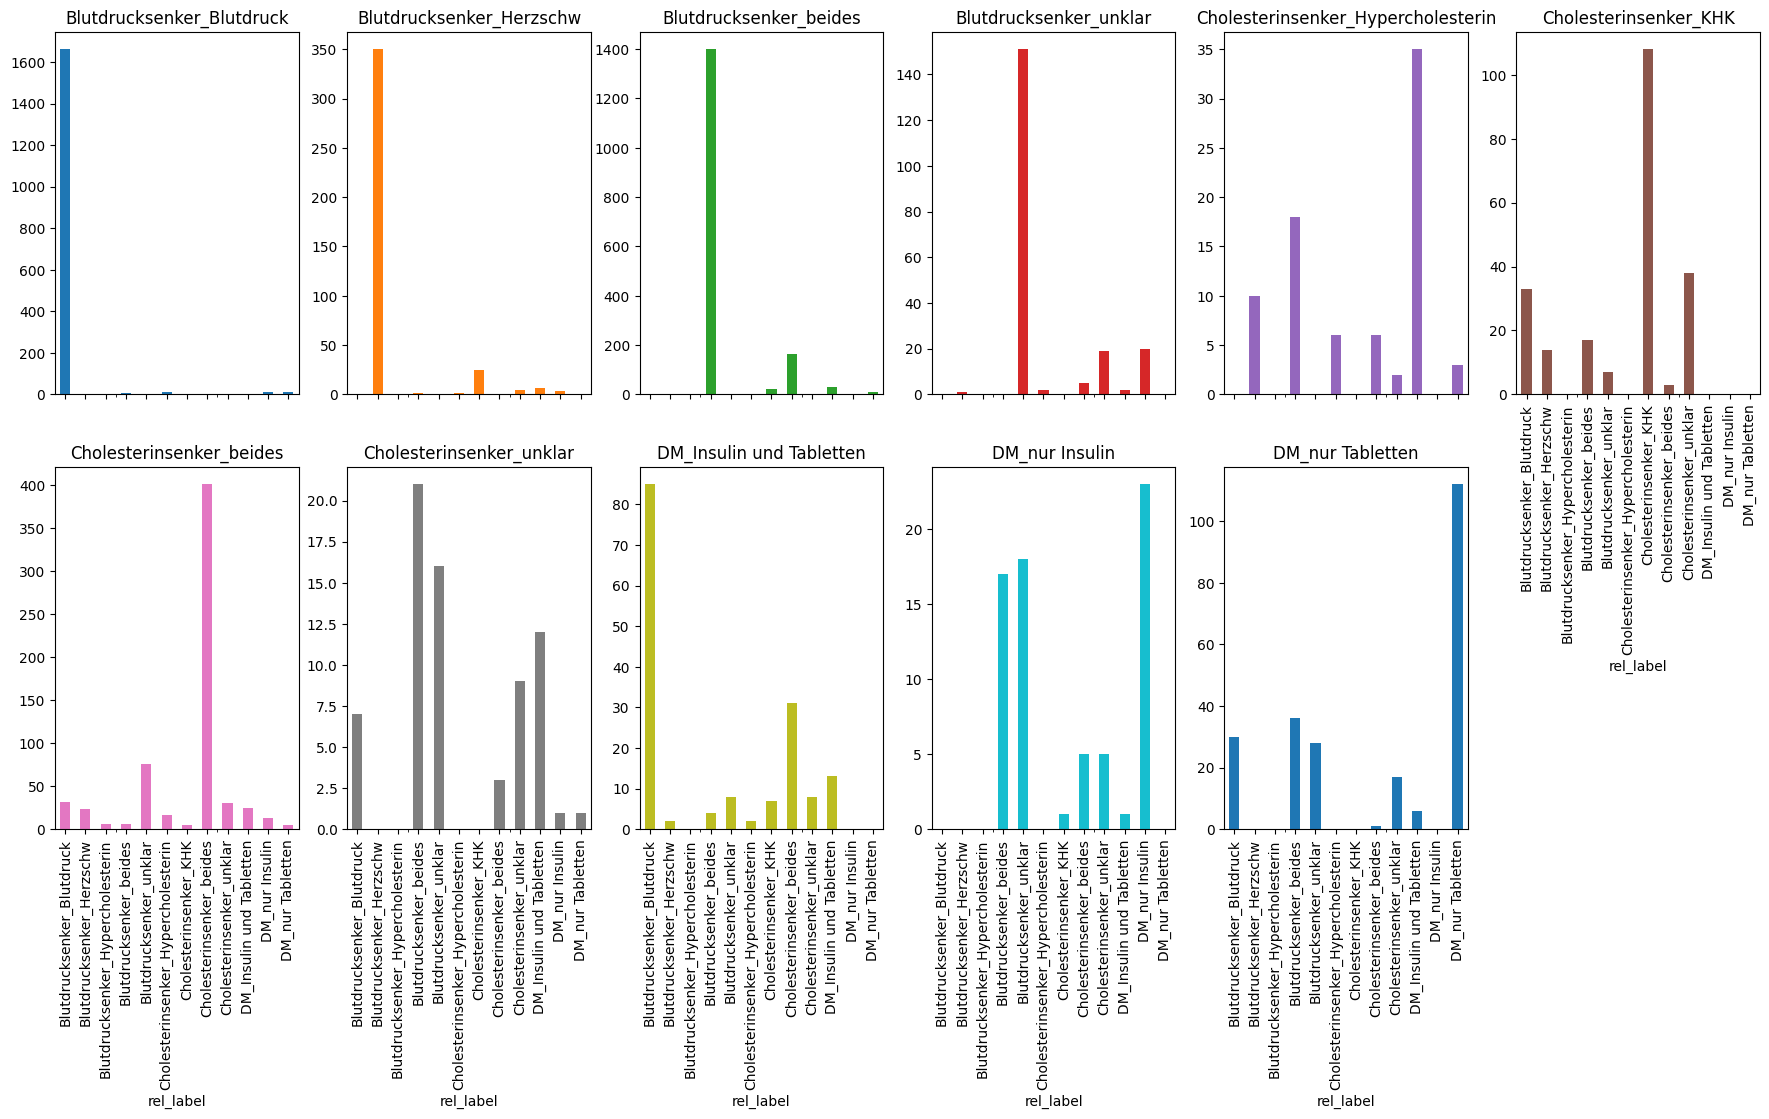

In [39]:
ig_gcn_bert_rel_label_vc = ig_gcn_bert_df.groupby("label")["rel_label"].value_counts()
ig_gcn_bert_rel_label_vc.unstack(level=0).plot(kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xlabel=None)

array([[<Axes: title={'center': 'Blutdrucksenker_Blutdruck'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_Herzschw'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_beides'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Blutdrucksenker_unklar'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_Hypercholesterin'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_KHK'}, xlabel='rel_label'>],
       [<Axes: title={'center': 'Cholesterinsenker_beides'}, xlabel='rel_label'>,
        <Axes: title={'center': 'Cholesterinsenker_unklar'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_Insulin und Tabletten'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_nur Insulin'}, xlabel='rel_label'>,
        <Axes: title={'center': 'DM_nur Tabletten'}, xlabel='rel_label'>,
        <Axes: xlabel='rel_label'>],
       [<Axes: xlabel='rel_label'>, <Axes: xlabel='rel_label'>,
        <A

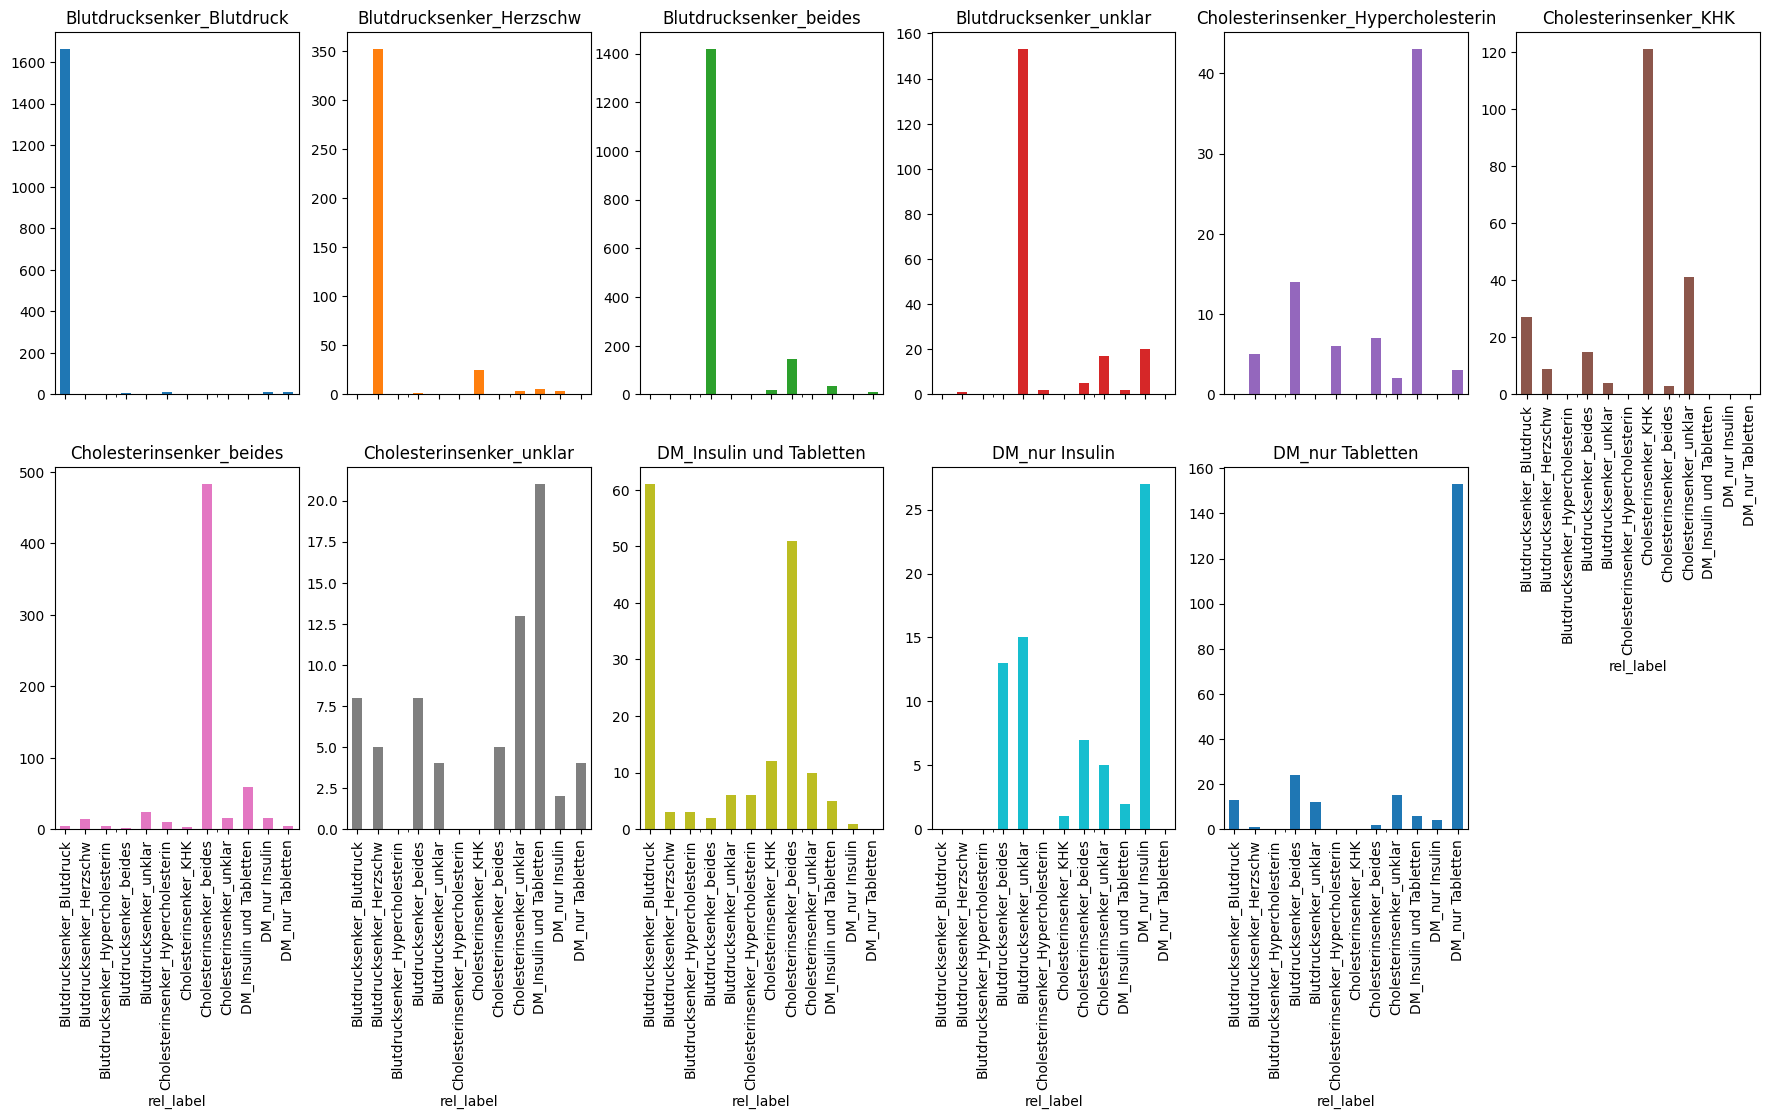

In [40]:
shap_gcn_bert_rel_doc_labels_vc = shap_gcn_bert_df.groupby("label")["rel_label"].value_counts()
shap_gcn_bert_rel_doc_labels_vc.unstack(level=0).plot(kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xlabel=None)